In [1]:
import pandas as pd

# Load the secondary sample matrix
df_sample = pd.read_csv('sample_matrix (1).csv')

print(f"Dataset shape: {df_sample.shape}")
print(df_sample.head())

Dataset shape: (456, 73)
             OS_STATUS studyID:sampleId     patientId  \
0  0:LIVING 1:DECEASED           string        string   
1                class             meta          meta   
2             0:LIVING  TCGA-A1-A0SB-01  TCGA-A1-A0SB   
3             0:LIVING  TCGA-A1-A0SN-01  TCGA-A1-A0SN   
4             0:LIVING  TCGA-A1-A0SQ-01  TCGA-A1-A0SQ   

                       OTHER_PATIENT_ID   OS_MONTHS        Random Forest  \
0                                string  continuous  0:LIVING 1:DECEASED   
1                                  meta        meta                 meta   
2  0045349c-69d9-4306-a403-c9c1fa836644     8.51498             0:LIVING   
3  0dc337fa-da8b-42c4-b9a7-fb76d81c161f     39.3201             0:LIVING   
4  08de63a2-7b76-43c3-80dc-df748b1d81bc     18.2135             0:LIVING   

   Logistic Regression                  SVM Random Forest (0:LIVING)  \
0  0:LIVING 1:DECEASED  0:LIVING 1:DECEASED               continuous   
1                 meta         

In [2]:
# Filter out any columns that belong to model predictions or IDs
cols_to_exclude = [col for col in df_sample.columns if any(model_name in col for model_name in ['Random Forest', 'Logistic Regression', 'SVM', 'id', 'ID'])]
df_clean = df_sample.drop(columns=[col for col in cols_to_exclude if col in df_sample.columns])

print(f"Cleaned feature matrix shape: {df_clean.shape}")

Cleaned feature matrix shape: (456, 61)


In [3]:
# Define target (OS_STATUS) and feature matrix (X)
y = df_clean['OS_STATUS']
X = df_clean.drop(columns=['OS_STATUS', 'OS_MONTHS', 'studyID', 'patientId', 'OTHER_PATIENT_ID'], errors='ignore')

print(f"Feature matrix X shape: {X.shape}")
print(f"Target vector y shape: {y.shape}")

Feature matrix X shape: (456, 58)
Target vector y shape: (456,)


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predict and evaluate
y_pred = rf_model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

ValueError: could not convert string to float: 'meta'

In [5]:
# Convert y to binary integers if it contains text labels
if y.dtype == 'object':
    y = y.str.contains('1|DECEASED|PROGRESSION', case=False, na=False).astype(int)

# Ensure all columns in X are numeric (one-hot encode any remaining text/categorical columns)
X_encoded = pd.get_dummies(X, drop_first=True)

# Re-split and train
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8913043478260869

Classification Report:
               precision    recall  f1-score   support

           0       0.89      1.00      0.94        77
           1       1.00      0.33      0.50        15

    accuracy                           0.89        92
   macro avg       0.94      0.67      0.72        92
weighted avg       0.90      0.89      0.87        92



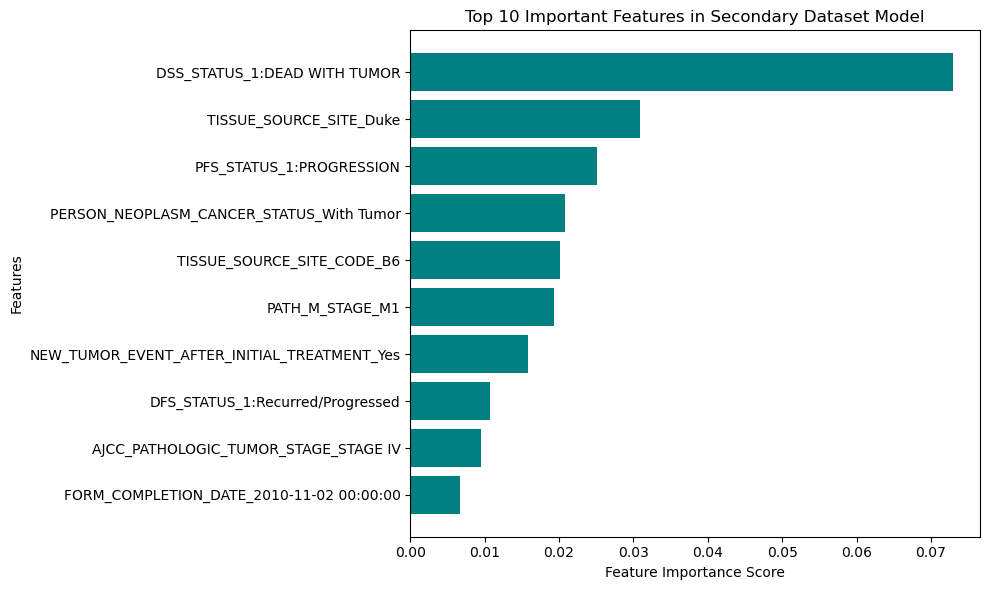

In [6]:
import matplotlib.pyplot as plt
import pandas as pd

# Get feature importances from the trained model
importances = rf_model.feature_importances_
feature_names = X_encoded.columns

# Create a dataframe for visualization
feature_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
# Sort to get the top 10 most important features
feature_imp_df = feature_imp_df.sort_values(by='Importance', ascending=False).head(10)

# Plot the top 10 features
plt.figure(figsize=(10, 6))
# Reverse the order so the highest is at the top of the bar chart
plt.barh(feature_imp_df['Feature'][::-1], feature_imp_df['Importance'][::-1], color='teal')
plt.xlabel('Feature Importance Score')
plt.ylabel('Features')
plt.title('Top 10 Important Features in Secondary Dataset Model')
plt.tight_layout()
plt.show()

Refined Accuracy: 0.8586956521739131

Classification Report:
               precision    recall  f1-score   support

           0       0.86      1.00      0.92        77
           1       1.00      0.13      0.24        15

    accuracy                           0.86        92
   macro avg       0.93      0.57      0.58        92
weighted avg       0.88      0.86      0.81        92



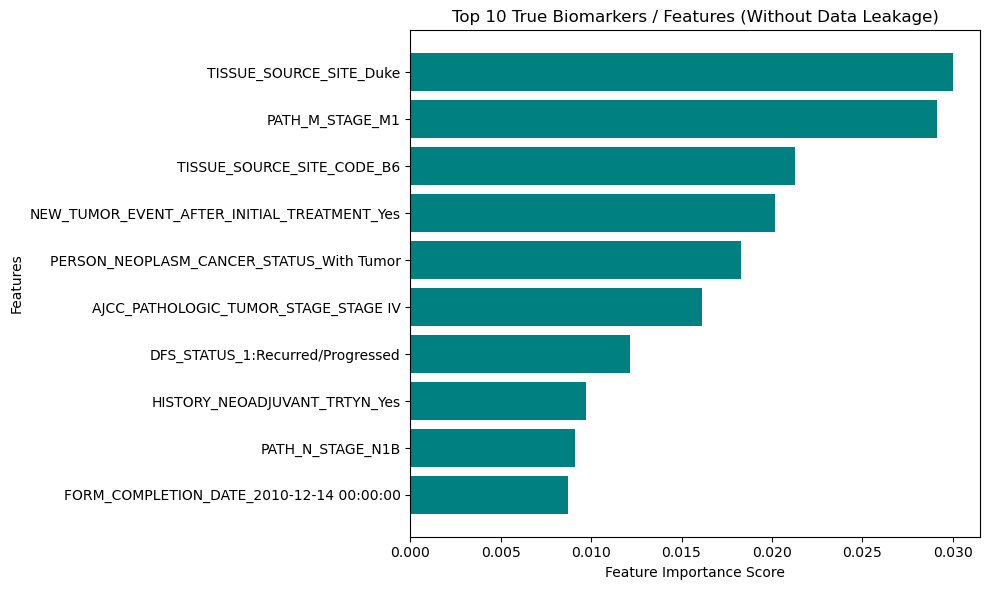

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt
import pandas as pd

# 1. Refine features by dropping outcome proxies (DSS/PFS), IDs, and target variables
cols_to_drop = ['OS_STATUS', 'OS_MONTHS', 'studyID', 'patientId', 'OTHER_PATIENT_ID']
dss_pfs_cols = [col for col in df_clean.columns if col.startswith(('DSS_', 'PFS_'))]

X_refined = df_clean.drop(columns=cols_to_drop + dss_pfs_cols, errors='ignore')
X_encoded_refined = pd.get_dummies(X_refined, drop_first=True)

# 2. Re-split and train the model
X_train, X_test, y_train, y_test = train_test_split(X_encoded_refined, y, test_size=0.2, random_state=42)

rf_model_refined = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model_refined.fit(X_train, y_train)

# 3. Evaluate
y_pred = rf_model_refined.predict(X_test)
print("Refined Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# 4. Plot True Feature Importances
importances = rf_model_refined.feature_importances_
feature_names = X_encoded_refined.columns
feature_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_imp_df = feature_imp_df.sort_values(by='Importance', ascending=False).head(10)

plt.figure(figsize=(10, 6))
plt.barh(feature_imp_df['Feature'][::-1], feature_imp_df['Importance'][::-1], color='teal')
plt.xlabel('Feature Importance Score')
plt.ylabel('Features')
plt.title('Top 10 True Biomarkers / Features (Without Data Leakage)')
plt.tight_layout()
plt.show()